Preprocessing
Before training, convert each raw document into a list of word tokens. You are expected to write this yourself, but the following pointers describe the approach so that everyone preprocesses the data consistently. You only need basic Python string methods — no special libraries are required.
• Strip the header. Each file begins with an email-style header (lines such as From:, Subject:, Organization:) followed by a blank line and then the message body. Keep only the body. Since a blank line appears in the text as "\n\n", you can use text.split("\n\n",1) to break the file into header and body, and keep the second part.
• Lowercase and split. Convert the text to lowercase with text.lower() and split it
into words with text.split() (which splits on spaces and newlines).
• Clean each word. Remove surrounding punctuation with word.strip(".,!?()[]:;") (add any other symbols you see). Keep a word only if it is alphabetic and longer than one character — word.isalpha() and len(word) > 1 are useful here. This discards numbers and punctuation-only tokens.
• Stopwords. For the stopword-removal part, read the Mallet en.txt list into a Python set (one word per line) and drop any token that is in it. Download the file and place it in your data folder. Checking membership against a set is fast.
A convenient design is to write a single tokenize(text) function that performs all the steps above (and optionally removes stopwords), then reuse it for every document in both the training and test sets.
Evaluation. Compute the accuracy and the confusion matrix, without a machine learning library. The accuracy is simply the fraction of test documents whose predicted class equals the true class. The confusion matrix is a 20 × 20 table whose entry (i, j) counts how many documents of true class i were predicted as class j; build it by counting over the test set, and display it with matplotlib (for example, plt.imshow).


In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import codecs
import os

DATA_ROOT = "/home/112401002/Documents/Sem 5/Introduction to Machine Learning DS3010/Lab 4/20news-bydate"
TRAIN_DIR = os.path.join(DATA_ROOT, "20news-bydate-train")
TEST_DIR = os.path.join(DATA_ROOT, "20news-bydate-test")
print(sorted(os.listdir(TRAIN_DIR))) # should list the 20 class folders

['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


Naı̈ve Bayes Classifier
1. Baseline classifier
(a) Load the training and test documents. For each document, remove the email-style header (the lines before the first blank line) and tokenize the remaining text into lowercase words.

In [105]:
docs = {}
for c in os.listdir(TRAIN_DIR):
    docs[c] = {}
    for file in os.listdir(os.path.join(TRAIN_DIR, c)):
        # print(f"Processing {file}")
        docs[c][file] = []
        with codecs.open(os.path.join(TRAIN_DIR, c, file), "r", encoding='utf-8',errors='ignore') as f:
            text = f.read()
            text = text.split("\n\n", 1)[1]
            words = text.lower().split()
            for word in words:
                word.strip(".,!?()[]:;")
                if word.isalpha() and len(word) > 1:
                    docs[c][file].append(word)

(b) Implement a multinomial Naı̈ve Bayes classifier from scratch. Estimate the class priors and the smoothed word likelihoods P (word | class) from the training set only. Use additive (Laplace) smoothing with α = 1. Perform all computations in log-space.

In [106]:
alpha = 1
total_docs = 0
total_words_in_class = {}
v = set()
P_k = {}
P_w_k = {}

for c in docs:
    total_docs += len(docs[c])
    total_words_in_class[c] = 0
    P_w_k[c] = {}

for c in docs:
    P_k[c] = len(docs[c])/total_docs
    for f in docs[c]:
        total_words_in_class[c] += len(docs[c][f])

for c in docs:
    seen_class = set()
    for f in docs[c]:
        for w in set(docs[c][f]):
            if w not in v:
                v.add(w)
            if w not in seen_class:
                seen_class.add(w)
                P_w_k[c][w] = alpha
            P_w_k[c][w] += docs[c][f].count(w)

for c in P_w_k:
    for w in P_w_k[c]:
        P_w_k[c][w] /= total_words_in_class[c] + len(v)*alpha

(c) Classify the test documents and report the overall classification accuracy.

In [107]:
docs_test = {}
for c in os.listdir(TEST_DIR):
    docs_test[c] = {}
    for file in os.listdir(os.path.join(TEST_DIR, c)):
        docs_test[c][file] = []
        with codecs.open(os.path.join(TEST_DIR, c, file), "r", encoding='utf-8',errors='ignore') as f:
            text = f.read()
            text = text.split("\n\n", 1)[1]
            words = text.lower().split()
            for word in words:
                word.strip(".,!?()[]:;")
                if word.isalpha() and len(word) > 1:
                    docs_test[c][file].append(word)

In [108]:
from collections import Counter

def predict(words):
    P_k_t = {}
    n_t_w = Counter(words)
    
    for c in docs:
        P_k_t[c] = np.log(P_k[c])
        denom = total_words_in_class[c] + len(v) * alpha
        unseen_logprob = np.log(alpha / denom)
        
        for w, count in n_t_w.items():
            if w not in v:
                continue
            if w in P_w_k[c]:
                P_k_t[c] += np.log(P_w_k[c][w]) * count
            else:
                P_k_t[c] += unseen_logprob * count

    return max(P_k_t, key=P_k_t.get)


labels = list(docs.keys())

confMatrix = np.zeros((20, 20))
for c in docs_test:
    for f in docs_test[c]:
        predicted = predict(docs_test[c][f])
        true = c
        confMatrix[labels.index(predicted), labels.index(true)] += 1

# print(confMatrix)

accuracy = np.trace(confMatrix)/np.sum(confMatrix)
print(f"Accuracy: {accuracy}")

Accuracy: 0.6925119490175252


(d) Compute and plot the confusion matrix for the 20 classes. Ensure the axes are clearly labelled.

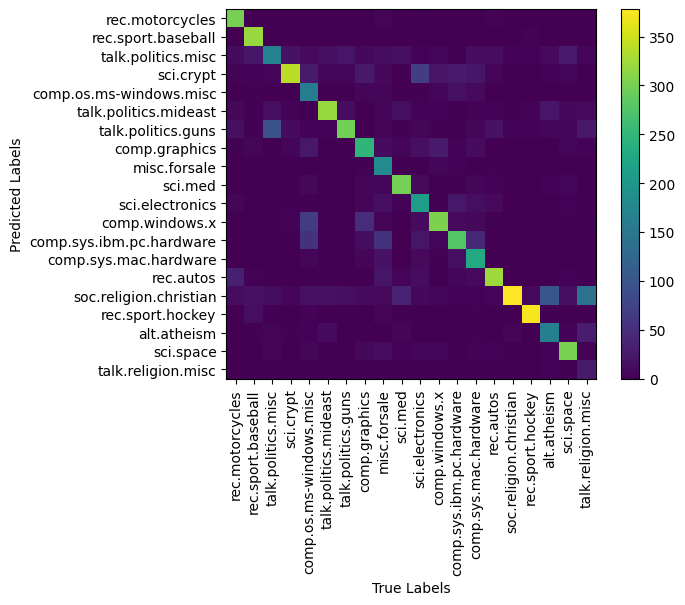

In [109]:
plt.imshow(confMatrix)
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.xlabel("True Labels")
plt.ylabel("Predicted Labels")
plt.colorbar()
# plt.tight_layout()
plt.show()

2. Effect of stopword removal
(a) Remove the stopwords from each document using the stopword list provided at: https://github.com/mimno/Mallet/blob/master/stoplists/en.txt

In [110]:
with open("stopwords.txt", "r") as f:
    stopwords = set(f.read().split())
docs_stopwords = {}
for c in docs:
    docs_stopwords[c] = {}
    for f in docs[c]:
        docs_stopwords[c][f] = []
        for w in docs[c][f]:
            if w not in stopwords:
                docs_stopwords[c][f].append(w)

docs_test_stopwords = {}
for c in docs_test:
    docs_test_stopwords[c] = {}
    for f in docs_test[c]:
        docs_test_stopwords[c][f] = []
        for w in docs_test[c][f]:
            if w not in stopwords:
                docs_test_stopwords[c][f].append(w)

(b) Train another Naı̈ve Bayes classifier (α = 1) on the stopword-removed documents and report its accuracy on the test set.

In [111]:
alpha = 1
total_docs_stopwords = 0
total_words_in_class_stopwords = {}
v_stopwords = set()
P_k_stopwords = {}
P_w_k_stopwords = {}

for c in docs_stopwords:
    total_docs_stopwords += len(docs_stopwords[c])
    total_words_in_class_stopwords[c] = 0
    P_w_k_stopwords[c] = {}

for c in docs_stopwords:
    P_k_stopwords[c] = len(docs_stopwords[c])/total_docs_stopwords
    for f in docs_stopwords[c]:
        total_words_in_class_stopwords[c] += len(docs_stopwords[c][f])

for c in docs_stopwords:
    seen_class = set()
    for f in docs_stopwords[c]:
        for w in set(docs_stopwords[c][f]):
            if w not in v_stopwords:
                v_stopwords.add(w)
            if w not in seen_class:
                seen_class.add(w)
                P_w_k_stopwords[c][w] = alpha
            P_w_k_stopwords[c][w] += docs_stopwords[c][f].count(w)

for c in P_w_k_stopwords:
    for w in P_w_k_stopwords[c]:
        P_w_k_stopwords[c][w] /= total_words_in_class_stopwords[c] + len(v_stopwords)*alpha

In [112]:
def predict_stopwords(words):
    P_k_t = {}
    n_t_w = Counter(words)
    
    for c in docs_stopwords:
        P_k_t[c] = np.log(P_k_stopwords[c])
        denom = total_words_in_class_stopwords[c] + len(v_stopwords) * alpha
        unseen_logprob = np.log(alpha / denom)
        
        for w, count in n_t_w.items():
            if w not in v_stopwords:
                continue
            if w in P_w_k_stopwords[c]:
                P_k_t[c] += np.log(P_w_k_stopwords[c][w]) * count
            else:
                P_k_t[c] += unseen_logprob * count

    return max(P_k_t, key=P_k_t.get)


labels = list(docs_stopwords.keys())

confMatrix_stopwords = np.zeros((20, 20))
for c in docs_test_stopwords:
    for f in docs_test_stopwords[c]:
        predicted = predict_stopwords(docs_test_stopwords[c][f])
        true = c
        confMatrix_stopwords[labels.index(predicted), labels.index(true)] += 1

# print(confMatrix_stopwords)

accuracy_stopwords = np.trace(confMatrix_stopwords)/np.sum(confMatrix_stopwords)
print(f"Accuracy: {accuracy_stopwords}")

Accuracy: 0.733935209771641


(c) Plot the confusion matrix for this classifier.

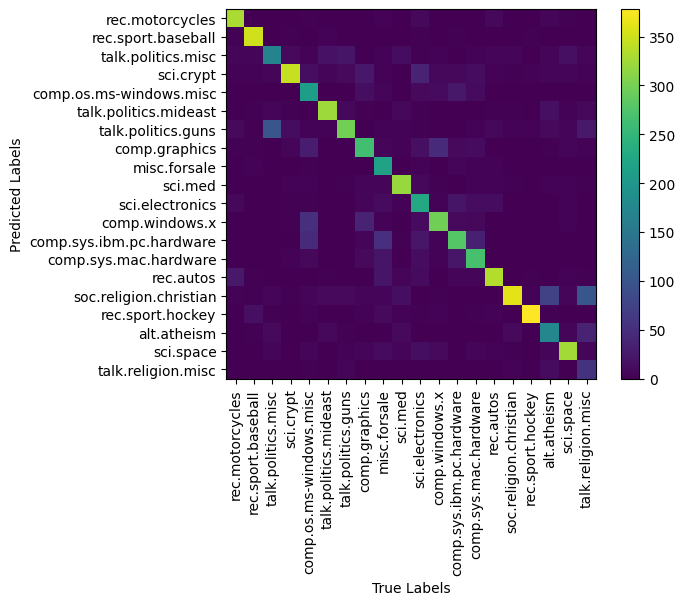

In [113]:
plt.imshow(confMatrix_stopwords)
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.xlabel("True Labels")
plt.ylabel("Predicted Labels")
plt.colorbar()
# plt.tight_layout()
plt.show()

3. Effect of the smoothing parameter
(a) Experiment with different values of the smoothing parameter α (for example, 0.001, 0.01, 0.1, 1, 10), for both the original and the stopword-removed versions.

In [114]:
def compute_f1(confMatrix):
    n_classes = confMatrix.shape[0]
    f1_scores = []
    for i in range(n_classes):
        tp = confMatrix[i, i]
        predicted_i = confMatrix[i, :].sum()
        true_i = confMatrix[:, i].sum()

        precision = tp / predicted_i if predicted_i > 0 else 0.0
        recall = tp / true_i if true_i > 0 else 0.0

        if precision + recall > 0:
            f1 = 2 * precision * recall / (precision + recall)
        else:
            f1 = 0.0
        f1_scores.append(f1)

    return np.mean(f1_scores)


accuracies = {}
f1_scores = {}
accuracies_stopwords = {}
f1_scores_stopwords = {}

for alpha in [0.001, 0.01, 0.1, 1, 10]:
    total_docs = 0
    total_words_in_class = {}
    v = set()
    P_k = {}
    P_w_k = {}

    for c in docs:
        total_docs += len(docs[c])
        total_words_in_class[c] = 0
        P_w_k[c] = {}

    for c in docs:
        P_k[c] = len(docs[c]) / total_docs
        for f in docs[c]:
            total_words_in_class[c] += len(docs[c][f])

    for c in docs:
        seen_class = set()
        for f in docs[c]:
            for w in set(docs[c][f]):
                if w not in v:
                    v.add(w)
                if w not in seen_class:
                    seen_class.add(w)
                    P_w_k[c][w] = alpha
                P_w_k[c][w] += docs[c][f].count(w)

    for c in P_w_k:
        for w in P_w_k[c]:
            P_w_k[c][w] /= total_words_in_class[c] + len(v) * alpha

    total_docs_stopwords = 0
    total_words_in_class_stopwords = {}
    v_stopwords = set()
    P_k_stopwords = {}
    P_w_k_stopwords = {}

    for c in docs_stopwords:
        total_docs_stopwords += len(docs_stopwords[c])
        total_words_in_class_stopwords[c] = 0
        P_w_k_stopwords[c] = {}

    for c in docs_stopwords:
        P_k_stopwords[c] = len(docs_stopwords[c]) / total_docs_stopwords
        for f in docs_stopwords[c]:
            total_words_in_class_stopwords[c] += len(docs_stopwords[c][f])

    for c in docs_stopwords:
        seen_class = set()
        for f in docs_stopwords[c]:
            for w in set(docs_stopwords[c][f]):
                if w not in v_stopwords:
                    v_stopwords.add(w)
                if w not in seen_class:
                    seen_class.add(w)
                    P_w_k_stopwords[c][w] = alpha
                P_w_k_stopwords[c][w] += docs_stopwords[c][f].count(w)

    for c in P_w_k_stopwords:
        for w in P_w_k_stopwords[c]:
            P_w_k_stopwords[c][w] /= total_words_in_class_stopwords[c] + len(v_stopwords) * alpha

    confMatrix_sweep = np.zeros((20, 20))
    for c in docs_test:
        for f in docs_test[c]:
            predicted = predict(docs_test[c][f])
            true = c
            confMatrix_sweep[labels.index(predicted), labels.index(true)] += 1

    f1_scores[alpha] = compute_f1(confMatrix_sweep)
    accuracies[alpha] = np.trace(confMatrix_sweep) / np.sum(confMatrix_sweep)

    confMatrix_stopwords_sweep = np.zeros((20, 20))
    for c in docs_test_stopwords:
        for f in docs_test_stopwords[c]:
            predicted = predict_stopwords(docs_test_stopwords[c][f])
            true = c
            confMatrix_stopwords_sweep[labels.index(predicted), labels.index(true)] += 1

    f1_scores_stopwords[alpha] = compute_f1(confMatrix_stopwords_sweep)
    accuracies_stopwords[alpha] = np.trace(confMatrix_stopwords_sweep) / np.sum(confMatrix_stopwords_sweep)

(b) Report the test accuracy for each value of α in a table.

In [115]:
accuracy_table = pd.DataFrame({"Alpha": list(accuracies.keys()),
                               "Accuracy": list(accuracies.values()),
                               "Accuracy(Stopwords)": [accuracies_stopwords[a] for a in accuracies.keys()]})
print(accuracy_table)

    Alpha  Accuracy  Accuracy(Stopwords)
0   0.001  0.738715             0.734466
1   0.010  0.743760             0.745353
2   0.100  0.749734             0.754116
3   1.000  0.692512             0.733935
4  10.000  0.231014             0.637679


Analysis
4. Print the classification performance (accuracy/F1) after removing stopwords, and after changing the smoothing parameter.

In [116]:
performances = {}
performances_stopwords = {}

for alpha in accuracies:
    performances[alpha] = accuracies[alpha] / f1_scores[alpha]
    performances_stopwords[alpha] = accuracies_stopwords[alpha] / f1_scores_stopwords[alpha]

accuracy_table = pd.DataFrame({"Alpha": list(performances.keys()),
                               "Performance": list(performances.values()),
                               "Performance(Stopwords)": [performances_stopwords[a] for a in performances.keys()]})
print(accuracy_table)

    Alpha  Performance  Performance(Stopwords)
0   0.001     1.012615                1.013503
1   0.010     1.012026                1.012848
2   0.100     1.011959                1.012721
3   1.000     1.027450                1.023125
4  10.000     1.211502                1.044010


5. Print the ten most probable words for each class from the trained Naı̈ve Bayes classifier.

In [117]:
for c in P_w_k:
    top_plain = sorted(P_w_k[c].items(), key=lambda x: x[1], reverse=True)[:10]
    top_sw = sorted(P_w_k_stopwords[c].items(), key=lambda x: x[1], reverse=True)[:10]

    df_class = pd.DataFrame({
        "Rank": range(1, 11),
        "Word (With Stopwords)": [w for w, p in top_plain],
        "Probability (With Stopwords)": [round(p, 5) for w, p in top_plain],
        "Word (Stopwords Removed)": [w for w, p in top_sw],
        "Probability (Stopwords Removed)": [round(p, 5) for w, p in top_sw],
    })

    print(f"Class: {c}")
    display(df_class)
    print()

Class: rec.motorcycles


,Rank,Word (With Stopwords),Probability (With Stopwords),Word (Stopwords Removed),Probability (Stopwords Removed)
0,1,the,0.00823,article,0.00082
1,2,to,0.00411,bike,0.00064
2,3,and,0.00314,dod,0.00054
3,4,of,0.00310,ride,0.00032
4,5,in,0.00269,good,0.00028
5,6,is,0.00199,motorcycle,0.00024
6,7,that,0.00176,make,0.00024
7,8,you,0.00170,back,0.00024
8,9,for,0.00169,bmw,0.00023
9,10,it,0.00165,riding,0.00021



Class: rec.sport.baseball


,Rank,Word (With Stopwords),Probability (With Stopwords),Word (Stopwords Removed),Probability (Stopwords Removed)
0,1,the,0.00890,article,0.00071
1,2,to,0.00376,good,0.00047
2,3,in,0.00338,team,0.00044
3,4,and,0.00326,year,0.00038
4,5,of,0.00299,game,0.00033
5,6,is,0.00217,hit,0.00031
6,7,that,0.00204,baseball,0.00031
7,8,he,0.00153,games,0.00028
8,9,for,0.00152,runs,0.00028
9,10,have,0.00122,players,0.00028



Class: talk.politics.misc


...

,Rank,Word (With Stopwords),Probability (With Stopwords),Word (Stopwords Removed),Probability (Stopwords Removed)
0,1,the,0.01080,people,0.00089
1,2,to,0.00637,article,0.00074
2,3,of,0.00629,god,0.00071
3,4,is,0.00508,make,0.00033
4,5,that,0.00449,atheists,0.00031
5,6,in,0.00393,evidence,0.00029
6,7,and,0.00391,things,0.00028
7,8,it,0.00266,time,0.00028
8,9,you,0.00260,good,0.00027
9,10,not,0.00225,religious,0.00026



Class: sci.space


,Rank,Word (With Stopwords),Probability (With Stopwords),Word (Stopwords Removed),Probability (Stopwords Removed)
0,1,the,0.01242,space,0.00155
1,2,of,0.00597,article,0.00067
2,3,to,0.00576,nasa,0.00053
3,4,and,0.00488,launch,0.00051
4,5,in,0.00398,lunar,0.00037
5,6,is,0.00311,data,0.00035
6,7,for,0.00248,shuttle,0.00033
7,8,that,0.00238,people,0.00032
8,9,on,0.00192,satellite,0.00031
9,10,it,0.00170,time,0.00028



Class: talk.religion.misc


,Rank,Word (With Stopwords),Probability (With Stopwords),Word (Stopwords Removed),Probability (Stopwords Removed)
0,1,the,0.01037,people,0.00059
1,2,of,0.00573,article,0.00056
2,3,to,0.00515,jesus,0.00050
3,4,and,0.00424,god,0.00045
4,5,that,0.00357,good,0.00029
5,6,in,0.00333,christian,0.00027
6,7,is,0.00326,bible,0.00026
7,8,you,0.00215,life,0.00022
8,9,not,0.00169,find,0.00020
9,10,it,0.00165,time,0.00020


6. Print the confusion matrix for the classifier.

In [118]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df_confmatrix = pd.DataFrame(confMatrix, index=labels, columns=labels)
df_confmatrix.index.name = "Predicted"
df_confmatrix.columns.name = "True"
print("Confusion Matrix (With Stopwords)")
display(df_confmatrix)

df_confmatrix_stopwords = pd.DataFrame(confMatrix_stopwords, index=labels, columns=labels)
df_confmatrix_stopwords.index.name = "Predicted"
df_confmatrix_stopwords.columns.name = "True"
print("Confusion Matrix (Stopwords Removed)")
display(df_confmatrix_stopwords)

Confusion Matrix (With Stopwords)


True,rec.motorcycles,rec.sport.baseball,talk.politics.misc,sci.crypt,comp.os.ms-windows.misc,talk.politics.mideast,talk.politics.guns,comp.graphics,misc.forsale,sci.med,sci.electronics,comp.windows.x,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,rec.autos,soc.religion.christian,rec.sport.hockey,alt.atheism,sci.space,talk.religion.misc
Predicted,,,,,,,,,,,,,,,,,,,,
rec.motorcycles,301.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,2.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
rec.sport.baseball,1.0,320.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0
talk.politics.misc,11.0,23.0,166.0,18.0,9.0,16.0,22.0,8.0,13.0,16.0,3.0,5.0,0.0,13.0,13.0,3.0,3.0,10.0,27.0,6.0
sci.crypt,3.0,3.0,6.0,339.0,28.0,5.0,7.0,26.0,8.0,1.0,69.0,20.0,27.0,23.0,5.0,1.0,1.0,3.0,7.0,1.0
comp.os.ms-windows.misc,1.0,2.0,0.0,1.0,160.0,0.0,0.0,7.0,6.0,0.0,2.0,5.0,17.0,9.0,1.0,0.0,0.0,0.0,1.0,0.0
talk.politics.mideast,8.0,2.0,14.0,3.0,0.0,318.0,13.0,1.0,5.0,14.0,4.0,3.0,1.0,3.0,4.0,2.0,4.0,22.0,8.0,9.0
talk.politics.guns,16.0,2.0,94.0,11.0,3.0,4.0,297.0,0.0,5.0,2.0,5.0,2.0,1.0,5.0,18.0,3.0,3.0,7.0,6.0,26.0
comp.graphics,2.0,6.0,0.0,5.0,25.0,1.0,1.0,247.0,11.0,5.0,15.0,28.0,4.0,11.0,1.0,1.0,0.0,1.0,7.0,3.0
misc.forsale,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,182.0,0.0,1.0,6.0,3.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0


Confusion Matrix (Stopwords Removed)


True,rec.motorcycles,rec.sport.baseball,talk.politics.misc,sci.crypt,comp.os.ms-windows.misc,talk.politics.mideast,talk.politics.guns,comp.graphics,misc.forsale,sci.med,sci.electronics,comp.windows.x,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,rec.autos,soc.religion.christian,rec.sport.hockey,alt.atheism,sci.space,talk.religion.misc
Predicted,,,,,,,,,,,,,,,,,,,,
rec.motorcycles,330.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,3.0,0.0,8.0,0.0,0.0,0.0,8.0,0.0,0.0,6.0,2.0,0.0
rec.sport.baseball,2.0,351.0,1.0,2.0,0.0,3.0,0.0,0.0,1.0,0.0,2.0,1.0,2.0,1.0,0.0,1.0,2.0,0.0,1.0,1.0
talk.politics.misc,6.0,7.0,169.0,9.0,4.0,18.0,22.0,1.0,4.0,12.0,2.0,3.0,1.0,3.0,7.0,5.0,1.0,6.0,16.0,6.0
sci.crypt,4.0,3.0,7.0,345.0,14.0,5.0,10.0,25.0,4.0,1.0,38.0,8.0,8.0,13.0,4.0,2.0,3.0,6.0,5.0,3.0
comp.os.ms-windows.misc,1.0,1.0,0.0,1.0,210.0,0.0,0.0,14.0,6.0,0.0,9.0,11.0,25.0,11.0,1.0,1.0,0.0,0.0,1.0,0.0
talk.politics.mideast,1.0,2.0,6.0,2.0,0.0,322.0,8.0,2.0,1.0,8.0,2.0,0.0,0.0,0.0,2.0,2.0,1.0,16.0,4.0,8.0
talk.politics.guns,10.0,2.0,99.0,13.0,4.0,4.0,298.0,0.0,4.0,4.0,2.0,0.0,1.0,3.0,8.0,4.0,3.0,9.0,5.0,26.0
comp.graphics,2.0,2.0,0.0,6.0,30.0,1.0,1.0,263.0,6.0,4.0,15.0,46.0,9.0,11.0,1.0,1.0,0.0,2.0,7.0,4.0
misc.forsale,1.0,3.0,0.0,1.0,2.0,0.0,1.0,0.0,218.0,1.0,3.0,1.0,5.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0
